# ⏩ Sequential Agent Workflows with Microsoft Foundry (Python)

## 📋 Sequential Processing Tutorial

This notebook demonstrates a **sequential workflow** using **Azure AI Foundry Agents** — three agents running in order, each passing its output to the next.

## 🎯 What We Build

A furniture pricing pipeline:

```
[User request]
    → Sales-Agent   (identifies furniture items from description)
    → Price-Agent   (provides pricing breakdown)
    → Quote-Agent   (formats a formal quote in Markdown)
```

## ⚙️ Prerequisites

### Environment variables (`.env`)
```env
AZURE_AI_PROJECT_ENDPOINT=https://<your-project>.services.ai.azure.com/api/projects/<project-id>
AZURE_AI_MODEL_DEPLOYMENT_NAME=gpt-4.1
```

### Authentication
```bash
az login
```

In [1]:
# ! pip install -r ../../../Installation/requirements.txt -U

In [2]:
import os
from typing import cast

from azure.identity.aio import AzureCliCredential
from dotenv import load_dotenv

from agent_framework.azure import AzureAIAgentsProvider
from agent_framework import (
    AgentExecutor,
    AgentResponse,
    WorkflowBuilder,
    WorkflowEvent,
    WorkflowViz,
)

In [3]:
load_dotenv()

True

In [4]:
SalesAgentName = "Sales-Agent"
SalesAgentInstructions = """You are a furniture sales consultant.
Identify different furniture elements from the user's description and give a purchase suggestion
listing each distinct furniture piece."""

PriceAgentName = "Price-Agent"
PriceAgentInstructions = """You are a furniture pricing specialist and budget consultant. Your responsibilities include:
1. Analyze furniture items and provide realistic price ranges based on quality, brand, and market standards
2. Break down pricing by individual furniture pieces
3. Provide budget-friendly alternatives and premium options
4. Consider different price tiers (budget, mid-range, premium)
5. Include estimated total costs for room setups
6. Suggest where to find the best deals and shopping recommendations
7. Factor in additional costs like delivery, assembly, and accessories
Always format your response with clear price breakdowns and explanations for the pricing rationale."""

QuoteAgentName = "Quote-Agent"
QuoteAgentInstructions = """You are an assistant that creates a formal quote for a furniture purchase.
Create a well-structured quote document that includes:
1. A title with the document title and date
2. An introduction summarizing the purpose of the document
3. A summary section with total estimated costs and recommendations
4. Use clear headings, bullet points, and tables for easy readability
All quotes are presented in Markdown format."""

Workflow visualization:
flowchart TD
  sales_agent["sales_agent (Start)"];
  price_agent["price_agent"];
  quote_agent["quote_agent"];
  sales_agent --> price_agent;
  price_agent --> quote_agent;


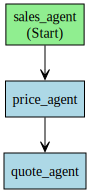

sales-agent: Great! You’ve already identified five key furniture elements for your living room. Below, I’ll outline each piece and suggest what to look for in each, and then recommend a mid-range option you might like.

1. **Sofa**  
- Look for: Comfortable seating, durable upholstery (like polyester blends or performance fabrics), and a style that complements the rest of your décor (mid-century, modern, etc.).  
- Suggestion: "IKEA KIVIK" or "West Elm Harris Sofa" – both offer comfort, quality, and a sleek look in a mid-range price.

2. **Coffee Table**  
- Look for: Sturdy construction (solid wood or metal), a style that works well with your sofa (rectangular for longer sofas, round for smaller spaces), and storage if needed.  
- Suggestion: "Article Taiga Coffee Table" (solid, minimalist wood) or "CB2 Peekaboo Acrylic Coffee Table" (modern, opens up space visually).

3. **Two Armchairs**  
- Look for: Chairs that complement but don’t match the sofa exactly (adds interest), comfortab

In [5]:
from IPython.display import SVG, display, HTML

sales_agent_obj = None
price_agent_obj = None
quote_agent_obj = None

async with (
    AzureCliCredential() as credential,
    AzureAIAgentsProvider(credential=credential) as provider,
):
    try:
        # Create agents in Azure AI Foundry
        sales_agent_obj = await provider.create_agent(
            name="sales-agent",
            instructions=SalesAgentInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        sales_agent = AgentExecutor(sales_agent_obj, id="sales_agent")

        price_agent_obj = await provider.create_agent(
            name="price-agent",
            instructions=PriceAgentInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        price_agent = AgentExecutor(price_agent_obj, id="price_agent")

        quote_agent_obj = await provider.create_agent(
            name="quote-agent",
            instructions=QuoteAgentInstructions,
            model=os.environ["AZURE_AI_MODEL_DEPLOYMENT_NAME"],
        )
        quote_agent = AgentExecutor(quote_agent_obj, id="quote_agent")

        # Build the sequential workflow: Sales → Price → Quote
        workflow = (
            WorkflowBuilder(start_executor=sales_agent)
            .add_edge(sales_agent, price_agent)
            .add_edge(price_agent, quote_agent)
            .build()
        )

        # Visualize
        print("Workflow visualization:")
        viz = WorkflowViz(workflow)
        print(viz.to_mermaid())
        svg_file = viz.export(format="svg")
        if svg_file and os.path.exists(svg_file):
            try:
                display(SVG(filename=svg_file))
            except Exception:
                with open(svg_file, "r", encoding="utf-8") as f:
                    display(HTML(f.read()))

        # Run the workflow with a text description
        user_request = (
            "I want to furnish my living room. It has a sofa, a coffee table, "
            "two armchairs, a bookshelf, and a floor lamp. Mid-range budget preferred."
        )

        events = await workflow.run(user_request)

        outputs = cast(list[AgentResponse], events.get_outputs())
        for output in outputs:
            print(f"{output.messages[0].author_name}: {output.text}\n")

        print("Final state:", events.get_final_state())

    finally:
        # Clean up agents from Azure AI Foundry
        for agent_obj in [sales_agent_obj, price_agent_obj, quote_agent_obj]:
            if agent_obj is not None:
                try:
                    await provider._agents_client.delete_agent(agent_obj.id)
                except Exception:
                    pass
        print("Agents cleaned up.")